# Projeto avaliativo: Preço de imovéis

Para esse projeto, nós do grupo 7, decidimos escolher uma base de dados do kaggle que trata da precificação de imovéis e como podemos prever isso com regressão, conforme link a seguir: https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/overview.

Nosso objetivo será realizar a analíse completa desse banco de dados e com isso usarmos a regressão juntamente com o Machine Learning para prever o valor de uma casa através das informações levantadas.

**Vamos lá!**

## Descrição do problema:

Este projeto tem como objetivo analisar um conjunto de dados imobiliários e desenvolver um modelo preditivo capaz de estimar o preço de venda de imóveis com base em suas características físicas, estruturais, localização e condições de venda.

O problema pode ser classificado como uma tarefa de regressão supervisionada, pois o conjunto de treinamento contém exemplos de imóveis já vendidos, acompanhados do respectivo valor de venda, representado pela variável SalePrice. A partir desses dados históricos, busca-se identificar padrões e relações entre as variáveis explicativas, como área construída, qualidade geral do imóvel, ano de construção, tamanho do lote, número de cômodos, garagem, localização e demais atributos, para prever o preço de imóveis ainda não avaliados.

Dessa forma, o trabalho propõe a realização de uma análise exploratória dos dados, o tratamento de valores ausentes e variáveis categóricas, a seleção de atributos relevantes e a aplicação de algoritmos de Machine Learning para construir um modelo capaz de prever preços de imóveis de maneira consistente. O desempenho do modelo poderá ser avaliado por meio de métricas adequadas para regressão, permitindo verificar sua capacidade de generalização para novos dados.

## Base de dados:

A base de dados utilizada neste projeto contém informações sobre imóveis residenciais e tem como objetivo apoiar a construção de um modelo preditivo para estimar o preço de venda das propriedades.

O conjunto de dados é composto por três arquivos principais:

- `train.csv`: conjunto de treinamento, contendo as características dos imóveis e a variável alvo `SalePrice`, que representa o preço de venda.
- `test.csv`: conjunto de teste, contendo as mesmas características dos imóveis, porém sem a variável `SalePrice`.
- `sample_submission.csv`: arquivo de exemplo com o formato esperado para a submissão das previsões.

Além desses arquivos, há também o arquivo `data_description.txt`, que apresenta a descrição detalhada de cada variável presente na base.

### Variável Alvo

A variável alvo do problema é:

- `SalePrice`: preço de venda do imóvel.

Como o objetivo é prever um valor numérico contínuo, este projeto caracteriza-se como um problema de regressão supervisionada.



### Variáveis Explicativas

A base possui diversas variáveis que descrevem aspectos físicos, estruturais e comerciais dos imóveis. Entre elas, destacam-se:

- `LotArea`: tamanho do terreno em pés quadrados.
- `OverallQual`: qualidade geral dos materiais e acabamentos do imóvel.
- `OverallCond`: condição geral de conservação do imóvel.
- `YearBuilt`: ano de construção.
- `YearRemodAdd`: ano da última reforma.
- `GrLivArea`: área habitável acima do solo.
- `TotalBsmtSF`: área total do porão.
- `GarageCars`: capacidade da garagem em número de carros.
- `GarageArea`: área da garagem.
- `FullBath`: número de banheiros completos.
- `BedroomAbvGr`: número de quartos acima do solo.
- `Neighborhood`: bairro onde o imóvel está localizado.
- `SaleCondition`: condição da venda.

### Importância da Base

Essa base permite investigar quais características têm maior influência no preço de venda dos imóveis. Por meio da análise exploratória e da aplicação de modelos de Machine Learning, é possível identificar padrões nos dados e construir um modelo capaz de estimar preços para novos imóveis.

Antes da modelagem, é necessário realizar etapas de preparação dos dados, como tratamento de valores ausentes, codificação de variáveis categóricas, análise de outliers e seleção de atributos relevantes.

## Análise Exploratória (EDA)

### Imports:

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

train = pd.read_csv("banco de dados/train.csv")
test = pd.read_csv("banco de dados/test.csv")

### Verificar número de linhas e colunas

In [58]:
train.shape
test.shape

(1459, 80)

### Identificar tipos de dados

In [59]:
train.dtypes
test.dtypes

Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
                  ...   
MiscVal            int64
MoSold             int64
YrSold             int64
SaleType             str
SaleCondition        str
Length: 80, dtype: object

### Observar algumas amostras do conjunto de dados

In [60]:
train.head()
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


### Observar amostras aleatórias

In [61]:
train.sample(5)
test.sample(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
327,1788,30,RL,90.0,5400,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2009,WD,Normal
1189,2650,120,RL,24.0,2280,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Normal
620,2081,50,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnWw,NaN,0,4,2008,WD,Normal
248,1709,20,FV,112.0,12606,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2009,WD,Normal
1311,2772,190,RL,70.0,7000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,3,2006,WD,Normal


### Identificar valores nulos

In [62]:
train.isnull().sum()
test.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64

### Identificar apenas colunas com valores nulos

In [63]:
train.isnull().sum()[train.isnull().sum() > 0]
test.isnull().sum()[test.isnull().sum() > 0]

MSZoning           4
LotFrontage      227
Alley           1352
Utilities          2
Exterior1st        1
Exterior2nd        1
MasVnrType       894
MasVnrArea        15
BsmtQual          44
BsmtCond          45
BsmtExposure      44
BsmtFinType1      42
BsmtFinSF1         1
BsmtFinType2      42
BsmtFinSF2         1
BsmtUnfSF          1
TotalBsmtSF        1
BsmtFullBath       2
BsmtHalfBath       2
KitchenQual        1
Functional         2
FireplaceQu      730
GarageType        76
GarageYrBlt       78
GarageFinish      78
GarageCars         1
GarageArea         1
GarageQual        78
GarageCond        78
PoolQC          1456
Fence           1169
MiscFeature     1408
SaleType           1
dtype: int64

### Tratar dados duplicados

In [64]:
train.duplicated().sum()
test.duplicated().sum()

train = train.drop_duplicates()
test = test.drop_duplicates()

### Corrigir inconsistências em textos

In [65]:
# Selecionar colunas de texto sem gerar warning
colunas_texto_train = train.select_dtypes(include="str").columns
colunas_texto_test = test.select_dtypes(include="str").columns

# Corrigir inconsistências em textos
train[colunas_texto_train] = train[colunas_texto_train].apply(lambda x: x.str.strip())
test[colunas_texto_test] = test[colunas_texto_test].apply(lambda x: x.str.strip())

train[colunas_texto_train] = train[colunas_texto_train].apply(lambda x: x.str.upper())
test[colunas_texto_test] = test[colunas_texto_test].apply(lambda x: x.str.upper())

### Ajustar formatos de datas

In [66]:
train["YearBuilt"] = pd.to_datetime(train["YearBuilt"], format="%Y")
train["YearRemodAdd"] = pd.to_datetime(train["YearRemodAdd"], format="%Y")
train["YrSold"] = pd.to_datetime(train["YrSold"], format="%Y")

test["YearBuilt"] = pd.to_datetime(test["YearBuilt"], format="%Y")
test["YearRemodAdd"] = pd.to_datetime(test["YearRemodAdd"], format="%Y")
test["YrSold"] = pd.to_datetime(test["YrSold"], format="%Y")

 ### Gerar estatísticas descritivas

### Selecionar apenas colunas numéricas

In [67]:
colunas_numericas_train = train.select_dtypes(include="number").columns
colunas_numericas_test = test.select_dtypes(include="number").columns

### Estatísticas descritivas do conjunto de treino

In [68]:
estatisticas_train = train[colunas_numericas_train].agg([
    "mean",
    "median",
    "min",
    "max",
    "std"
])

estatisticas_train

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,SalePrice
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,103.685262,443.639726,46.549315,567.240411,...,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,180921.195890
median,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,0.000000,383.500000,0.000000,477.500000,...,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,163000.000000
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,34900.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,1600.000000,5644.000000,1474.000000,2336.000000,...,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,755000.000000
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,181.066207,456.098091,161.319273,441.866955,...,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,79442.502883


### Estatísticas descritivas do conjunto de teste

In [69]:
estatisticas_test = test[colunas_numericas_test].agg([
    "mean",
    "median",
    "min",
    "max",
    "std"
])

estatisticas_test

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold
mean,2190.000000,57.378341,68.580357,9819.161069,6.078821,5.553804,100.709141,439.203704,52.619342,554.294925,...,1.766118,472.768861,93.174777,48.313914,24.243317,1.794380,17.064428,1.744345,58.167923,6.104181
median,2190.000000,50.000000,67.000000,9399.000000,6.000000,5.000000,0.000000,350.500000,0.000000,460.000000,...,2.000000,480.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000
min,1461.000000,20.000000,21.000000,1470.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,2919.000000,190.000000,200.000000,56600.000000,10.000000,9.000000,1290.000000,4010.000000,1526.000000,2140.000000,...,5.000000,1488.000000,1424.000000,742.000000,1012.000000,360.000000,576.000000,800.000000,17000.000000,12.000000
std,421.321334,42.746880,22.376841,4955.517327,1.436812,1.113740,177.625900,455.268042,176.753926,437.260486,...,0.775945,217.048611,127.744882,68.883364,67.227765,20.207842,56.609763,30.491646,630.806978,2.722432


In [70]:
train.to_csv("banco de dados/train_tratado.csv", index=False)
test.to_csv("banco de dados/test_tratado.csv", index=False)

## Visualização dos dados

### Gráfico de barras: quantidade de imóveis por bairro

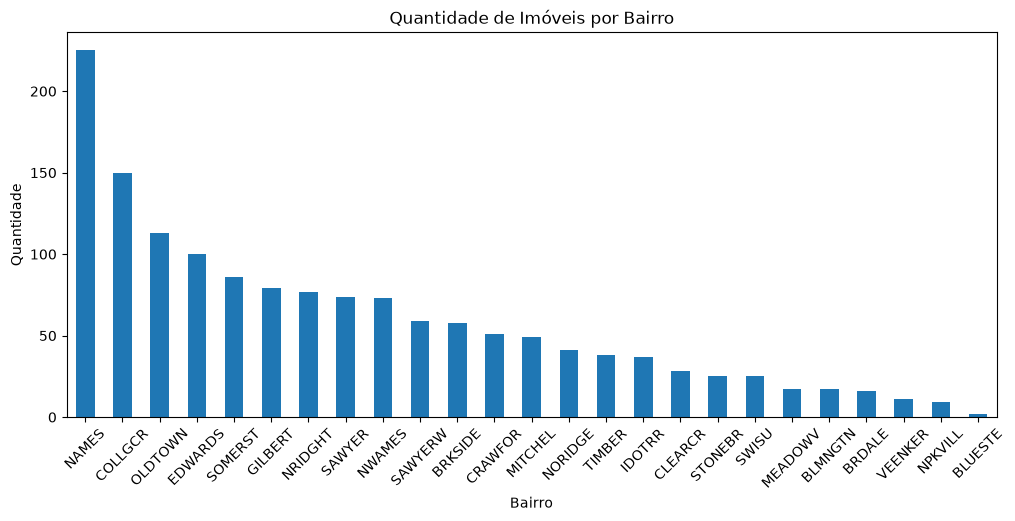

In [71]:
train["Neighborhood"].value_counts().plot(kind="bar", figsize=(12, 5))
plt.title("Quantidade de Imóveis por Bairro")
plt.xlabel("Bairro")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.show()

In [72]:
plt.savefig("imagens/graficoBarras.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

### Histograma: distribuição dos preços dos imóveis

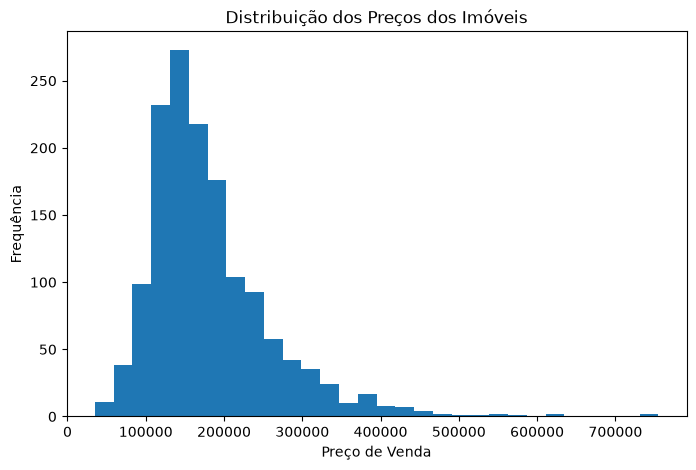

In [73]:
plt.figure(figsize=(8, 5))
plt.hist(train["SalePrice"], bins=30)
plt.title("Distribuição dos Preços dos Imóveis")
plt.xlabel("Preço de Venda")
plt.ylabel("Frequência")
plt.show()

In [74]:
plt.savefig("imagens/histograma", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

### Boxplot: preços dos imóveis

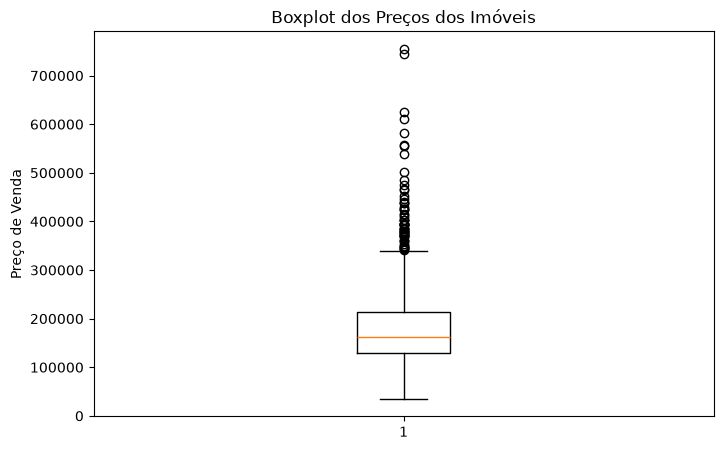

In [75]:
plt.figure(figsize=(8, 5))
plt.boxplot(train["SalePrice"])
plt.title("Boxplot dos Preços dos Imóveis")
plt.ylabel("Preço de Venda")
plt.show()

In [76]:
plt.savefig("imagens/boxplot.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

### Gráfico de dispersão: área habitável x preço de venda

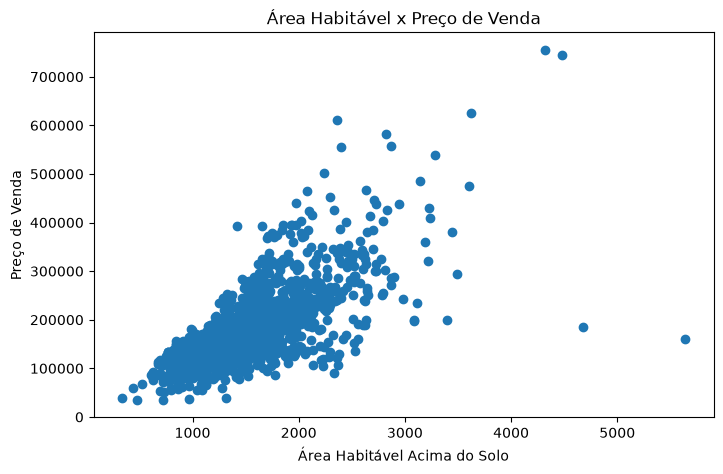

In [77]:
plt.figure(figsize=(8, 5))
plt.scatter(train["GrLivArea"], train["SalePrice"])
plt.title("Área Habitável x Preço de Venda")
plt.xlabel("Área Habitável Acima do Solo")
plt.ylabel("Preço de Venda")
plt.show()

In [78]:
plt.savefig("imagens/graficoDispersao.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

### Matriz de correlação com heatmap usando matplotlib

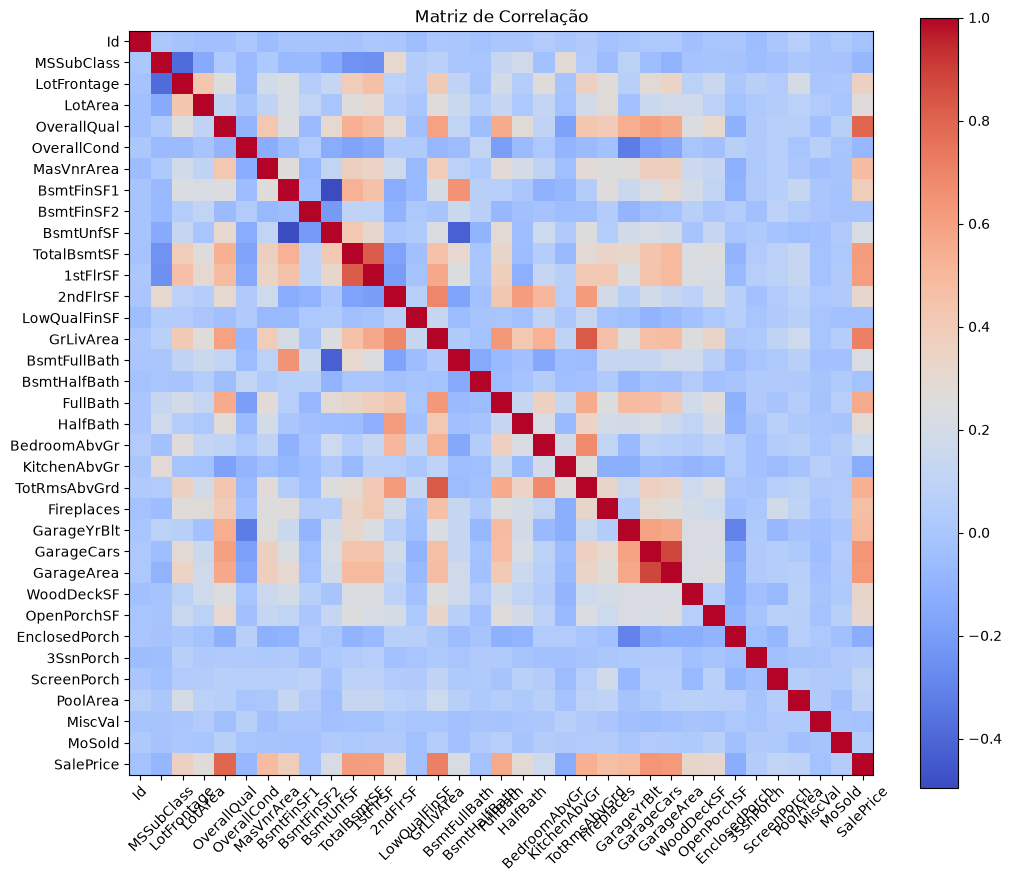

In [79]:
correlacao = train.select_dtypes(include="number").corr()

plt.figure(figsize=(12, 10))
plt.imshow(correlacao, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.title("Matriz de Correlação")
plt.xticks(range(len(correlacao.columns)), correlacao.columns, rotation=45)
plt.yticks(range(len(correlacao.columns)), correlacao.columns)
plt.show()

In [80]:
plt.savefig("imagens/matrixDeCorrelacao.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>